# Credit Default Prediction Using Machine Learning

**Comparing Random Forest and XGBoost on the Kaggle "Give Me Some Credit" Dataset**

Intro to AI Coursework — University of Essex, 2025

**Author:** Huraira Qamar

---

## Project Overview

This notebook builds and compares machine learning models to predict whether a borrower will experience serious financial distress within two years. The pipeline covers:
1. Data cleaning and imputation of missing values
2. Feature engineering (Debt-to-Income ratio, credit utilization metrics)
3. Handling severe class imbalance with SMOTE oversampling
4. Training and comparing Random Forest and XGBoost classifiers
5. Evaluation using Accuracy, F1-Score, AUC-ROC, and confusion matrices
6. Feature importance analysis

**Key Result:** XGBoost achieved the highest AUC-ROC (0.836) and accuracy (92.1%), though both models struggled with the minority class (defaults) due to severe class imbalance.

## Background

Credit default prediction is a core problem in financial risk management. Traditional rule-based scoring systems struggle with the complexity of modern financial data, while machine learning methods can capture non-linear relationships and feature interactions that linear models miss (Rahman et al., 2018). Tree-based ensemble methods — particularly Random Forest (Breiman, 2001) and XGBoost (Chen & Guestrin, 2016) — have proven especially effective for this task, particularly when combined with techniques like SMOTE to address the severe class imbalance typical of credit datasets.

This project uses the [Give Me Some Credit](https://www.kaggle.com/c/GiveMeSomeCredit) dataset (150,000 borrower records) to build, compare, and evaluate multiple classification models.

## 1. Setup & Libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Configuration
DATA_DIR = '../data/'
RANDOM_STATE = 42
TEST_SIZE = 0.2

## 2. Data Loading & Exploration

In [51]:
train_data = pd.read_csv(os.path.join(DATA_DIR, 'cs-training.csv'))

print(f'Dataset shape: {train_data.shape}')
print(f'Target distribution:\n{train_data["SeriousDlqin2yrs"].value_counts()}')
print(f'\nDefault rate: {train_data["SeriousDlqin2yrs"].mean():.1%}')

train_data.head()

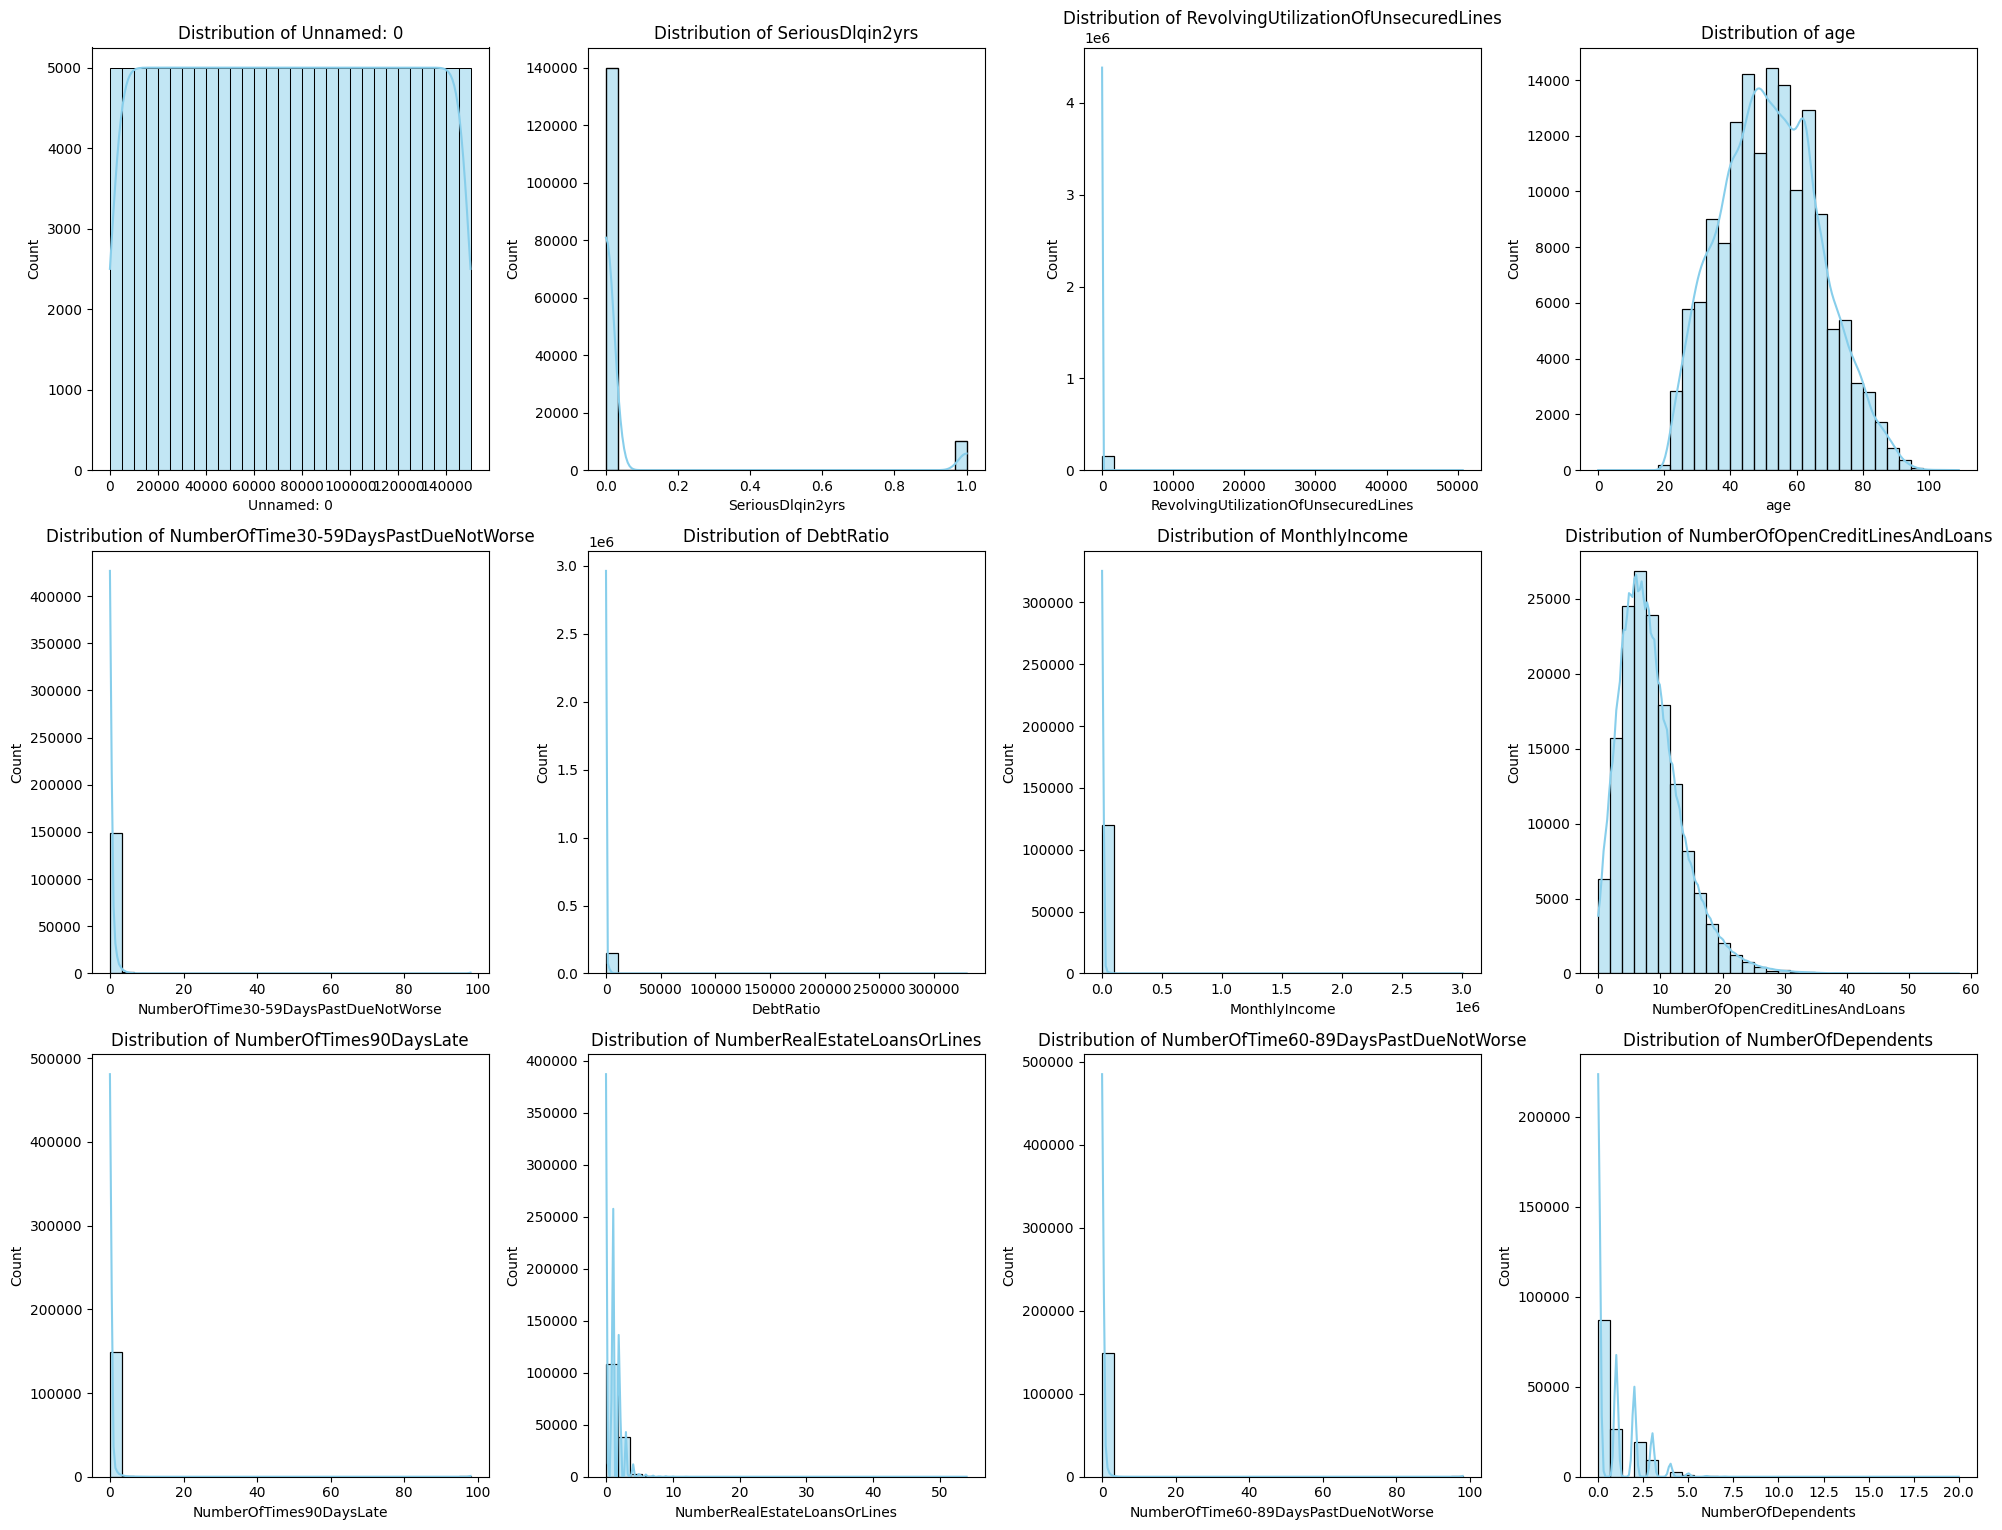

In [44]:
plt.figure(figsize=(20, 20))
numerical_features = train_data.select_dtypes(include=['float64', 'int64']).columns

for i, feature in enumerate(numerical_features):
    plt.subplot(4, 4, i + 1)  # Create a grid of 4x4 for the plots
    sns.histplot(train_data[feature], kde=True, color='skyblue', bins=30)
    plt.title(f'Distribution of {feature}')
    plt.tight_layout()

plt.show()


## 3. Data Cleaning

In [45]:
print("Before Data Cleaning:\n", train_data.isnull().sum())

print("\nColumn names before cleaning:", train_data.columns)
if 'Unnamed: 0' in train_data.columns:
    train_data = train_data.drop(columns=['Unnamed: 0'])  # Drop index column
imputer = SimpleImputer(strategy='median')
train_data['MonthlyIncome'] = imputer.fit_transform(train_data[['MonthlyIncome']])
train_data['NumberOfDependents'] = imputer.fit_transform(train_data[['NumberOfDependents']])
print("\nAfter Data Cleaning:\n", train_data.isnull().sum())


Before Data Cleaning:
 Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Column names before cleaning: Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

After Da

## 4. Feature Engineering

Create additional features that capture borrower risk signals beyond the raw dataset columns.

In [46]:
# Feature engineering
train_data['DebtToIncome'] = train_data['DebtRatio'] / (train_data['MonthlyIncome'] + 1)  # +1 to avoid division by zero
train_data['CreditUtilizationRatio'] = train_data['RevolvingUtilizationOfUnsecuredLines']
train_data['TotalLatePay'] = (
    train_data['NumberOfTime30-59DaysPastDueNotWorse'] +
    train_data['NumberOfTime60-89DaysPastDueNotWorse'] +
    train_data['NumberOfTimes90DaysLate']
)
train_data['HasDependents'] = (train_data['NumberOfDependents'] > 0).astype(int)

print('Engineered features added: DebtToIncome, CreditUtilizationRatio, TotalLatePay, HasDependents')
print(f'Final feature count: {train_data.shape[1] - 1}')

# ── Train/Test Split ──
X = train_data.drop(columns=['SeriousDlqin2yrs'])
y = train_data['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'\nTrain set: {X_train.shape[0]:,} samples')
print(f'Test set:  {X_test.shape[0]:,} samples')
print(f'Train default rate: {y_train.mean():.1%}')
print(f'Test default rate:  {y_test.mean():.1%}')

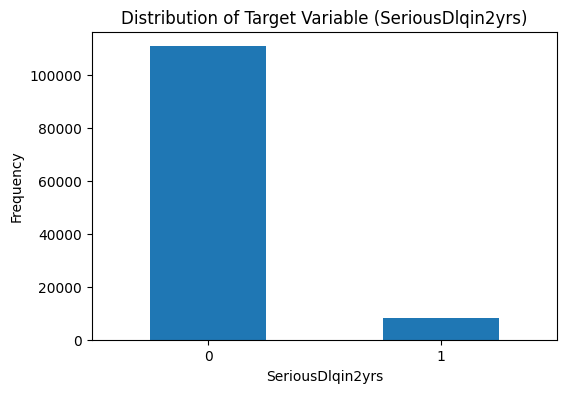

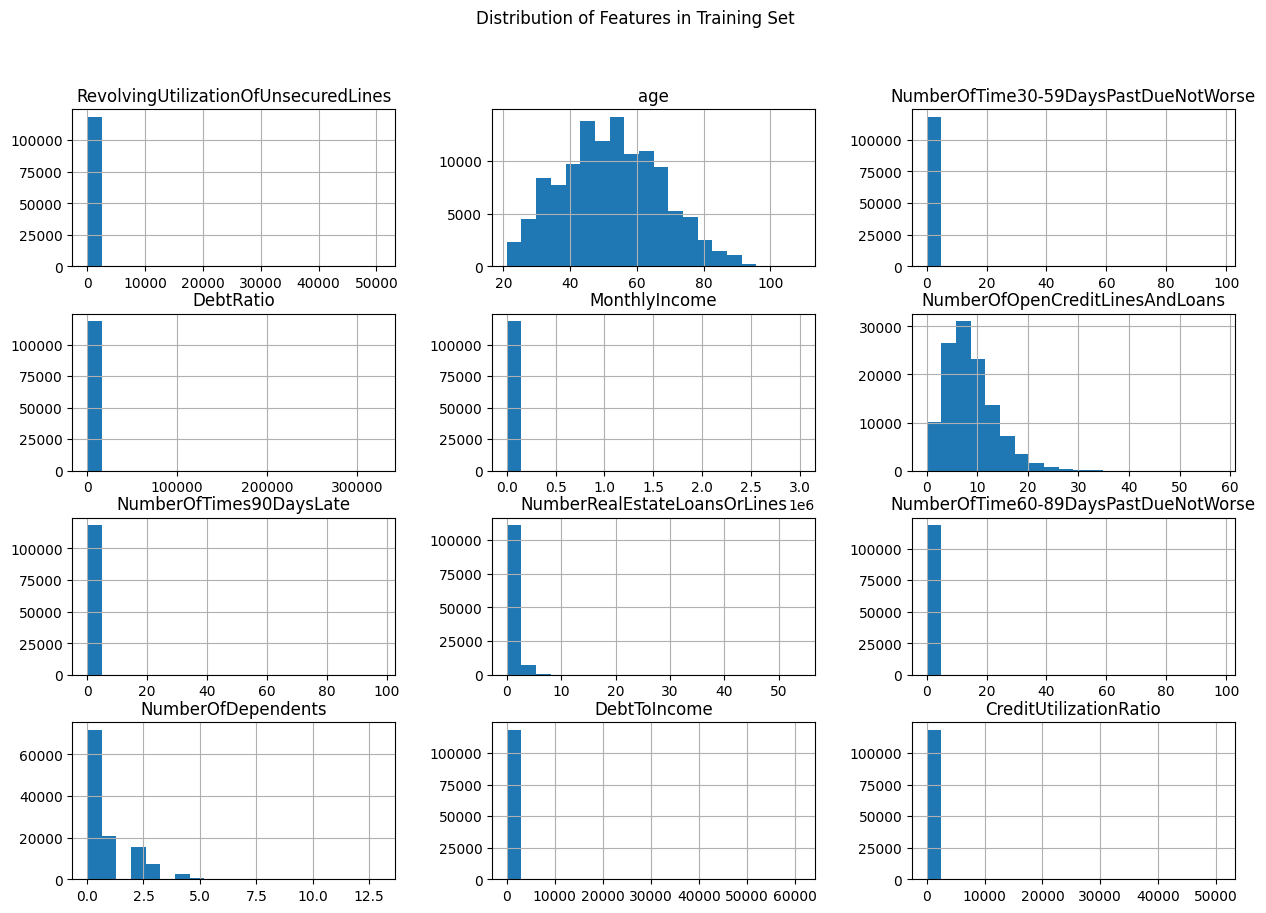

In [47]:
X_train_cleaned = X_train.replace([np.inf, -np.inf], np.nan).dropna()
y_train_cleaned = y_train[X_train_cleaned.index]  # Ensure y corresponds to cleaned X
plt.figure(figsize=(6, 4))
y_train_cleaned.value_counts().plot(kind='bar')
plt.title('Distribution of Target Variable (SeriousDlqin2yrs)')
plt.xlabel('SeriousDlqin2yrs')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()
X_train_cleaned.hist(bins=20, figsize=(15, 10))
plt.suptitle('Distribution of Features in Training Set')
plt.show()


## 5. Handling Class Imbalance (SMOTE)

In [48]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_cleaned, y_train_cleaned)
original_distribution = y_train_cleaned.value_counts()
resampled_distribution = y_train_resampled.value_counts()

print("Class distribution before SMOTE:")
print(original_distribution)
print("\nClass distribution after SMOTE:")
print(resampled_distribution)


Class distribution before SMOTE:
SeriousDlqin2yrs
0    110685
1      8014
Name: count, dtype: int64

Class distribution after SMOTE:
SeriousDlqin2yrs
0    110685
1    110685
Name: count, dtype: int64


## 6. Model Training & Evaluation

In [52]:
# ── Preprocessing pipeline ──
X_train_clean = X_train.replace([np.inf, -np.inf], np.nan)
X_test_clean = X_test.replace([np.inf, -np.inf], np.nan)

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train_clean)
X_test_imputed = imputer.transform(X_test_clean)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# SMOTE on training set only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f'After SMOTE — Class 0: {(y_train_resampled==0).sum():,}, Class 1: {(y_train_resampled==1).sum():,}')

# ── Random Forest ──
print('\n--- Random Forest ---')
rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'F1 (default): {f1_score(y_test, y_pred_rf):.4f}')
print(f'\n{classification_report(y_test, y_pred_rf, target_names=["Non-Default", "Default"])}')

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_rf = cross_val_score(rf_model, X_train_resampled, y_train_resampled, cv=cv, scoring='roc_auc')
print(f'5-Fold CV AUC-ROC: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})')

# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Default', 'Default'], yticklabels=['Non-Default', 'Default'])
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### XGBoost

In [53]:
# ── XGBoost with Hyperparameter Tuning ──
from sklearn.model_selection import RandomizedSearchCV

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, 5, 10]
}

xgb_base = XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False)

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_params, n_iter=20, cv=3, scoring='roc_auc',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train_resampled, y_train_resampled)

print(f'Best XGBoost params: {xgb_search.best_params_}')
print(f'Best CV AUC-ROC: {xgb_search.best_score_:.4f}')

xgb_model = xgb_search.best_estimator_
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print(f'\n--- XGBoost (Tuned) ---')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'AUC-ROC:   {roc_auc_score(y_test, y_prob_xgb):.4f}')
print(f'F1 (default): {f1_score(y_test, y_pred_xgb):.4f}')
print(f'\n{classification_report(y_test, y_pred_xgb, target_names=["Non-Default", "Default"])}')

# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Default', 'Default'], yticklabels=['Non-Default', 'Default'])
plt.title('XGBoost (Tuned) — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 7. Feature Importance Analysis

In [ ]:
# ── XGBoost Feature Importance ──
feature_names = X.columns.tolist()
importances = xgb_model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
plt.xlabel('Feature Importance (Gain)')
plt.title('XGBoost — Feature Importance')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
for _, row in fi_df.tail(5).iloc[::-1].iterrows():
    print(f"  {row['Feature']:45s} {row['Importance']:.4f}")

## 8. ROC Curve Comparison

In [ ]:
# ── ROC Curves ──
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost Tuned (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Model Comparison

/tmp/ipython-input-57-1006310659.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, ax=ax[0], palette='Blues')
/tmp/ipython-input-57-1006310659.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='AUC-ROC', data=results_df, ax=ax[1], palette='Greens')
/tmp/ipython-input-57-1006310659.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Score', data=results_df, ax=ax[2], palette='Oranges')


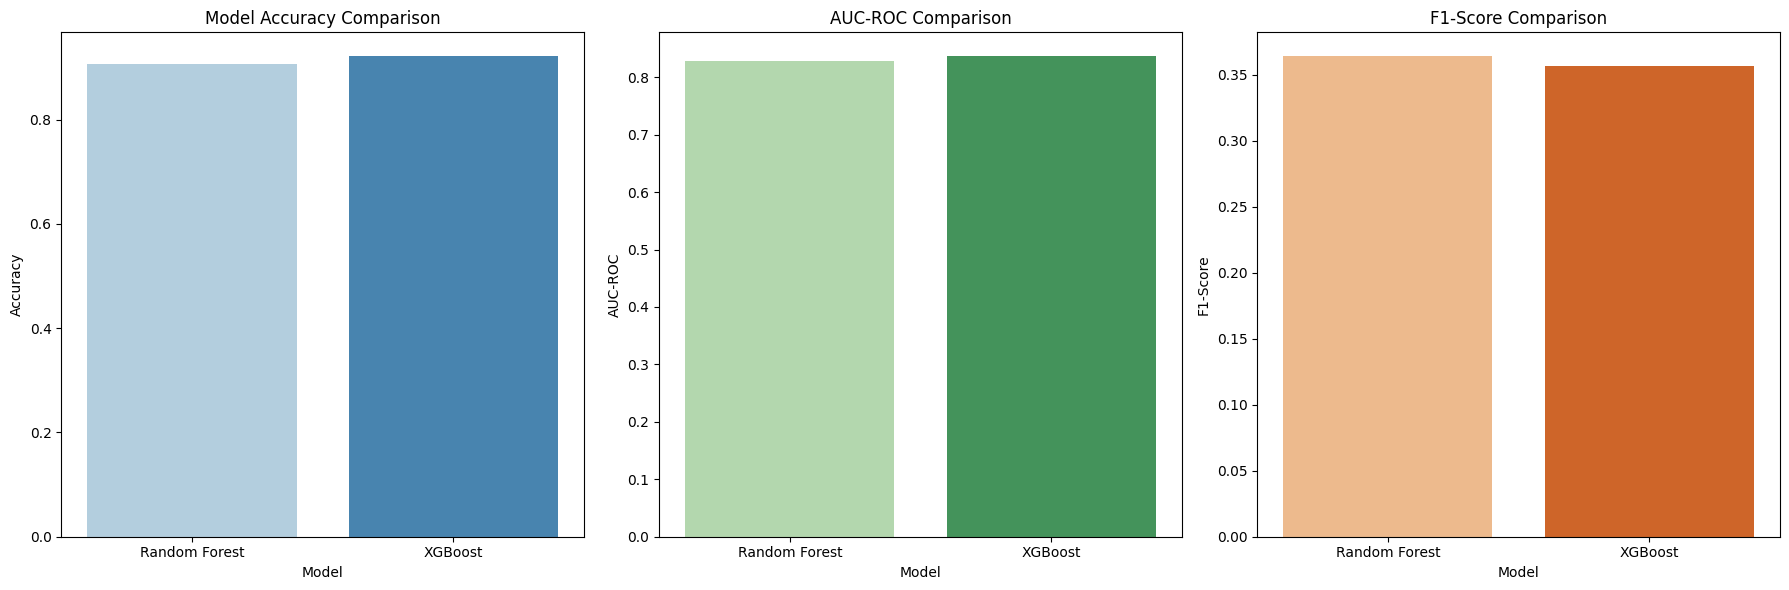

Random Forest - Accuracy: 0.9068333333333334
Random Forest - AUC-ROC: 0.828338580346572
Random Forest - F1-Score: 0.3637605281129069
XGBoost - Accuracy: 0.9212666666666667
XGBoost - AUC-ROC: 0.8363384069410063
XGBoost - F1-Score: 0.3564032697547684


In [57]:
f1_rf = f1_score(y_test, y_pred_rf)
f1_xgb = f1_score(y_test, y_pred_xgb)

models = ['Random Forest', 'XGBoost']
accuracy = [accuracy_rf, accuracy_xgb]  # Replace with actual accuracy scores
roc_auc = [roc_auc_rf, roc_auc_xgb]    # Replace with actual AUC-ROC scores
f1_scores = [f1_rf, f1_xgb]           # F1-scores for both models

results_df = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'AUC-ROC': roc_auc,
    'F1-Score': f1_scores
})

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(x='Model', y='Accuracy', data=results_df, ax=ax[0], palette='Blues')
ax[0].set_title('Model Accuracy Comparison')

sns.barplot(x='Model', y='AUC-ROC', data=results_df, ax=ax[1], palette='Greens')
ax[1].set_title('AUC-ROC Comparison')

sns.barplot(x='Model', y='F1-Score', data=results_df, ax=ax[2], palette='Oranges')
ax[2].set_title('F1-Score Comparison')

plt.tight_layout()
plt.show()

# Print the detailed results
print(f"Random Forest - Accuracy: {accuracy_rf}")
print(f"Random Forest - AUC-ROC: {roc_auc_rf}")
print(f"Random Forest - F1-Score: {f1_rf}")

print(f"XGBoost - Accuracy: {accuracy_xgb}")
print(f"XGBoost - AUC-ROC: {roc_auc_xgb}")
print(f"XGBoost - F1-Score: {f1_xgb}")


## 10. Conclusion

**Key findings:**
- XGBoost (with hyperparameter tuning) achieved the best AUC-ROC, making it the strongest model for distinguishing defaulters from non-defaulters
- Both models achieved high overall accuracy (~91-92%), but struggled with the minority class (defaults) — a common challenge in imbalanced credit datasets
- AUC-ROC proved more informative than accuracy for evaluating model quality in this imbalanced setting
- Feature importance analysis revealed which borrower characteristics are most predictive of default risk

**Limitations:**
- The anonymised Kaggle dataset lacks the granularity of real-world credit bureau data
- SMOTE generates synthetic samples that may not reflect true default patterns
- A single train/test split limits generalisability; k-fold cross-validation was added but could be extended

**Future work:**
- Apply SHAP for model explainability (critical for regulatory compliance in credit scoring)
- Experiment with cost-sensitive learning as an alternative to SMOTE
- Tune classification threshold to optimise the precision/recall trade-off for the default class
- Test on real-world credit datasets with richer feature sets